In [2]:
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import re

bucket_name = "dsan6000-dx64"
prefix = "wikipedia-hourly/"

s3 = boto3.client("s3", region_name="us-east-1")
response = s3.list_objects_v2(Bucket=bucket_name, Prefix=prefix)

dfs = []
for obj in response.get("Contents", []):
    key = obj["Key"]
    if key.endswith(".parquet"):
        uri = f"s3://{bucket_name}/{key}"
        df = pd.read_parquet(uri)
        match = re.search(r"(\d{8}_\d{6})", key)
        df["hour"] = match.group(1) if match else key
        dfs.append(df)

all_events = pd.concat(dfs, ignore_index=True)

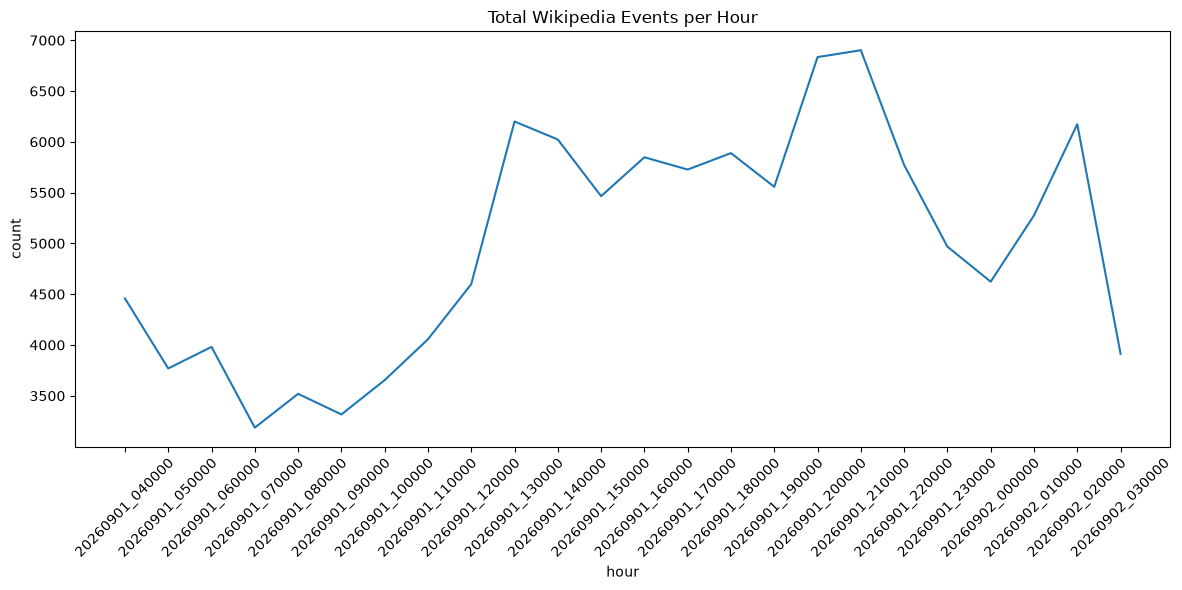

In [3]:
os.makedirs("images", exist_ok=True)

hourly_counts = all_events.groupby("hour").size().reset_index(name="count")
hourly_counts = hourly_counts.sort_values("hour")

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_counts, x="hour", y="count")
plt.xticks(rotation=45)
plt.title("Total Wikipedia Events per Hour")
plt.tight_layout()
plt.savefig("images/hourly-events.svg")
plt.savefig("images/hourly-events.png")
plt.show()

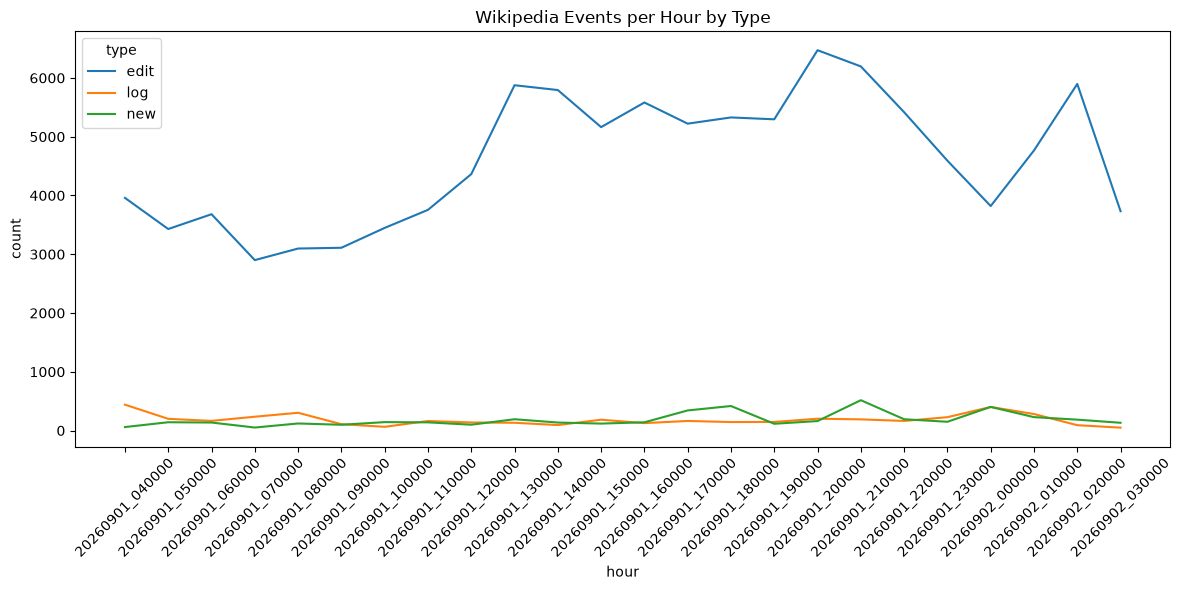

In [4]:
type_counts = all_events.groupby(["hour", "type"]).size().reset_index(name="count")
type_counts = type_counts.sort_values("hour")

plt.figure(figsize=(12, 6))
sns.lineplot(data=type_counts, x="hour", y="count", hue="type")
plt.xticks(rotation=45)
plt.title("Wikipedia Events per Hour by Type")
plt.tight_layout()
plt.savefig("images/events-by-type.svg")
plt.savefig("images/events-by-type.png")
plt.show()